<a href="https://colab.research.google.com/github/maromarokinoko/TOEIC_word_me/blob/main/TEST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# TensorFlowを最新版で入れ直します（数分かかります）
!pip install tensorflow keras pillow numpy

  Using cached tensorflow-2.20.0-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (4.5 kB)
  Using cached keras-3.13.2-py3-none-any.whl.metadata (6.3 kB)
Using cached tensorflow-2.20.0-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (620.7 MB)
Using cached keras-3.13.2-py3-none-any.whl (1.5 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-decision-forests 1.12.0 requires tensorflow==2.19.0, but you have tensorflow 2.20.0 which is incompatible.
tf-keras 2.19.0 requires tensorflow<2.20,>=2.19, but you have tensorflow 2.20.0 which is incompatible.
tensorflow-text 2.19.0 requires tensorflow<2.20,>=2.19.0, but you have tensorflow 2.20.0 which is incompatible.


1/1 [==============================] - 1s 1s/step
------------------------------
【判定結果】: まる
【自信度】: 99.96%
------------------------------


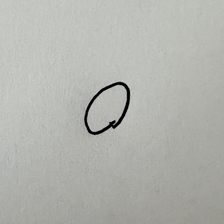

In [1]:
import os
# 最新版KerasでTeachable Machineを動かすための設定
os.environ['TF_USE_LEGACY_KERAS'] = '1'

import tensorflow as tf
from tensorflow.keras.models import load_model
from PIL import Image, ImageOps
import numpy as np

# --- 魔法の力技（groupsエラー回避） ---
import keras
if not hasattr(keras.layers.DepthwiseConv2D, '__init___old'):
    old_init = keras.layers.DepthwiseConv2D.__init__
    def new_init(self, *args, **kwargs):
        kwargs.pop('groups', None)
        return old_init(self, *args, **kwargs)
    keras.layers.DepthwiseConv2D.__init__ = new_init
    keras.layers.DepthwiseConv2D.__init___old = old_init

# 1. モデルとラベルの読み込み（フォルダ名を正確に指定）
# スクリーンショットを見ると、sample_dataの中にファイルがあります
model_path = "sample_data/keras_model.h5"
label_path = "sample_data/labels.txt"

model = load_model(model_path, compile=False)
class_names = open(label_path, "r").readlines()

# 2. 判定したい画像を開く
image_path = "sample_data/TEST_1.PNG"
image = Image.open(image_path).convert("RGB")

# 3. 前処理
size = (224, 224)
image = ImageOps.fit(image, size, Image.Resampling.LANCZOS)
image_array = np.asarray(image)
normalized_image_array = (image_array.astype(np.float32) / 127.5) - 1

data = np.ndarray(shape=(1, 224, 224, 3), dtype=np.float32)
data[0] = normalized_image_array

# 4. 予測
prediction = model.predict(data)
index = np.argmax(prediction)
class_name = class_names[index]
confidence_score = prediction[0][index]

# 5. 結果表示
print("-" * 30)
print("【判定結果】:", class_name[2:].strip())
print("【自信度】:", f"{confidence_score * 100:.2f}%")
print("-" * 30)
display(image)